In [11]:
## CIFAR-10 CNN — Notebook 2: Augmentation, Tuning & Transfer Learning

#**Contents:** Data augmentation setup, Models 3-7
#(dropout, extended training, learning rate tuning, VGG16 transfer learning),
#full evaluation (confusion matrix, classification report) for best model.

#**Best model:** Model 5 — 77.4% validation accuracy

In [1]:
#Erste Zelle im neuen Notebook — alles Nötige auf einmal laden

from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import pandas as pd
import pickle
import os
from tensorflow.keras import layers, models

data_path = '/content/drive/MyDrive/cifar10-project/data'

X_train_final = np.load(f'{data_path}/X_train_final.npy')
y_train_final = np.load(f'{data_path}/y_train_final.npy')
X_val = np.load(f'{data_path}/X_val.npy')
y_val = np.load(f'{data_path}/y_val.npy')
X_test_norm = np.load(f'{data_path}/X_test_norm.npy')
y_test = np.load(f'{data_path}/y_test.npy')

print("Daten geladen:", X_train_final.shape, X_val.shape, X_test_norm.shape)

Mounted at /content/drive
Daten geladen: (45000, 32, 32, 3) (5000, 32, 32, 3) (10000, 32, 32, 3)


In [2]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

datagen.fit(X_train_final)

In [3]:
#Model 3 same as Model 2 Architectur

model_3 = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_3.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [4]:
#Training Model 3, mit datagen (Augumentation Data)
history_3 = model_3.fit(
    datagen.flow(X_train_final, y_train_final, batch_size=64),
    validation_data=(X_val, y_val),
    epochs=10
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 35s 44ms/step - accuracy: 0.3691 - loss: 1.6964 - val_accuracy: 0.4566 - val_loss: 1.4780
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 28s 39ms/step - accuracy: 0.5021 - loss: 1.3815 - val_accuracy: 0.5492 - val_loss: 1.2615
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 28s 39ms/step - accuracy: 0.5561 - loss: 1.2459 - val_accuracy: 0.6128 - val_loss: 1.1119
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 28s 40ms/step - accuracy: 0.5890 - loss: 1.1549 - val_accuracy: 0.6416 - val_loss: 0.9962
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 28s 40ms/step - accuracy: 0.6130 - loss: 1.0965 - val_accuracy: 0.6224 - val_loss: 1.0696
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 29s 41ms/step - accuracy: 0.6300 - loss: 1.0485 - val_accuracy: 0.6648 - val_loss: 0.9421
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 28s 40ms/step - accuracy: 0.6466 - loss: 1.0083 - val_accuracy: 0.6770 - val_loss: 0.9226
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 28s 40ms/step - accuracy: 0.6566 - loss: 0.9783 - 

In [6]:
#Results Älte + Model 3 kommt dazu

results = [
    {
        'Model': 'Model 1',
        'Architecture': '3 Conv layers (32-64-64)',
        'Learning Rate': 'default (Adam)',
        'Epochs': 10,
        'Train Accuracy': '74.03%',
        'Val Accuracy': '68.70%',
        'Test Accuracy': '68.00%',
        'Notes': 'Baseline. Train/Val-Luecke 5.3%, leichtes Overfitting ab Epoch 5'
    },
    {
        'Model': 'Model 2',
        'Architecture': '3 Conv layers (32-64-128)',
        'Learning Rate': 'default (Adam)',
        'Epochs': 10,
        'Train Accuracy': '79.01%',
        'Val Accuracy': '71.10%',
        'Test Accuracy': '70.58%',
        'Notes': 'Mehr Filter in letztem Conv-Layer (64->128). Besser als Modell 1, Luecke etwas groesser (7.9%)'
    }
]

In [7]:
#Evaluieren, speichern, tracken
test_loss_3, test_accuracy_3 = model_3.evaluate(X_test_norm, y_test)
print(f"Test Accuracy: {test_accuracy_3:.2%}")

models_path = '/content/drive/MyDrive/cifar10-project/models'
with open(f'{models_path}/model_3_augmented.pkl', 'wb') as f:
    pickle.dump(model_3, f)

train_acc_3 = history_3.history['accuracy'][-1]
val_acc_3 = history_3.history['val_accuracy'][-1]
gap_3 = train_acc_3 - val_acc_3

results.append({
    'Model': 'Model 3',
    'Architecture': '3 Conv layers (32-64-128) + Data Augmentation',
    'Learning Rate': 'default (Adam)',
    'Epochs': 10,
    'Train Accuracy': f"{train_acc_3:.2%}",
    'Val Accuracy': f"{val_acc_3:.2%}",
    'Test Accuracy': f"{test_accuracy_3:.2%}",
    'Notes': f"Mit Augmentation (Rotation, Shift, Flip). Train/Val-Luecke {gap_3:.1%} (kein Overfitting mehr!). Aehnliche Val-Acc wie Modell 2, aber robuster"
})

pd.DataFrame(results)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7053 - loss: 0.8642
Test Accuracy: 70.53%


,Model,Architecture,Learning Rate,Epochs,Train Accuracy,Val Accuracy,Test Accuracy,Notes
0,Model 1,3 Conv layers (32-64-64),default (Adam),10,74.03%,68.70%,68.00%,"Baseline. Train/Val-Luecke 5.3%, leichtes Over..."
1,Model 2,3 Conv layers (32-64-128),default (Adam),10,79.01%,71.10%,70.58%,Mehr Filter in letztem Conv-Layer (64->128). B...
2,Model 3,3 Conv layers (32-64-128) + Data Augmentation,default (Adam),10,67.76%,70.54%,70.53%,"Mit Augmentation (Rotation, Shift, Flip). Trai..."


In [8]:
#Model 4 Mit Dropout

model_4 = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_4.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
#Trainigt fit Combi : Data Augumentation + Dropout
history_4 = model_4.fit(
    datagen.flow(X_train_final, y_train_final, batch_size=64),
    validation_data=(X_val, y_val),
    epochs=10
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 35s 44ms/step - accuracy: 0.3726 - loss: 1.7076 - val_accuracy: 0.4916 - val_loss: 1.3574
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 28s 40ms/step - accuracy: 0.5020 - loss: 1.3811 - val_accuracy: 0.5428 - val_loss: 1.2879
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 28s 39ms/step - accuracy: 0.5464 - loss: 1.2655 - val_accuracy: 0.5802 - val_loss: 1.2032
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 27s 39ms/step - accuracy: 0.5821 - loss: 1.1768 - val_accuracy: 0.6256 - val_loss: 1.0416
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 28s 39ms/step - accuracy: 0.6051 - loss: 1.1193 - val_accuracy: 0.6424 - val_loss: 1.0194
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 28s 39ms/step - accuracy: 0.6227 - loss: 1.0675 - val_accuracy: 0.6574 - val_loss: 0.9631
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 28s 39ms/step - accuracy: 0.6309 - loss: 1.0450 - val_accuracy: 0.6824 - val_loss: 0.8982
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 28s 40ms/step - accuracy: 0.6450 - loss: 1.0092 - 

In [10]:
#Evaluieren, Speichern, tracken
test_loss_4, test_accuracy_4 = model_4.evaluate(X_test_norm, y_test)
print(f"Test Accuracy: {test_accuracy_4:.2%}")

with open(f'{models_path}/model_4_dropout.pkl', 'wb') as f:
    pickle.dump(model_4, f)

train_acc_4 = history_4.history['accuracy'][-1]
val_acc_4 = history_4.history['val_accuracy'][-1]
gap_4 = train_acc_4 - val_acc_4

results.append({
    'Model': 'Model 4',
    'Architecture': '3 Conv layers (32-64-128) + Augmentation + Dropout(0.3)',
    'Learning Rate': 'default (Adam)',
    'Epochs': 10,
    'Train Accuracy': f"{train_acc_4:.2%}",
    'Val Accuracy': f"{val_acc_4:.2%}",
    'Test Accuracy': f"{test_accuracy_4:.2%}",
    'Notes': f"Dropout zusaetzlich zu Augmentation. Keine Verbesserung ggue. Modell 3 (Luecke {gap_4:.1%}) - Augmentation allein reichte bereits"
})

pd.DataFrame(results)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6859 - loss: 0.9056
Test Accuracy: 68.59%


,Model,Architecture,Learning Rate,Epochs,Train Accuracy,Val Accuracy,Test Accuracy,Notes
0,Model 1,3 Conv layers (32-64-64),default (Adam),10,74.03%,68.70%,68.00%,"Baseline. Train/Val-Luecke 5.3%, leichtes Over..."
1,Model 2,3 Conv layers (32-64-128),default (Adam),10,79.01%,71.10%,70.58%,Mehr Filter in letztem Conv-Layer (64->128). B...
2,Model 3,3 Conv layers (32-64-128) + Data Augmentation,default (Adam),10,67.76%,70.54%,70.53%,"Mit Augmentation (Rotation, Shift, Flip). Trai..."
3,Model 4,3 Conv layers (32-64-128) + Augmentation + Dro...,default (Adam),10,66.52%,68.16%,68.59%,Dropout zusaetzlich zu Augmentation. Keine Ver...


In [11]:
#Model 5 (Mehr Epochs kommt im Trainig)
#Identisch zu Modell 3 (kein Dropout, da es nicht geholfen hat)
model_5 = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_5.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
# 25 Epochs statt 10 mit Early Stopping
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True
)

history_5 = model_5.fit(
    datagen.flow(X_train_final, y_train_final, batch_size=64),
    validation_data=(X_val, y_val),
    epochs=25,
    callbacks=[early_stop]
)

Epoch 1/25
704/704 ━━━━━━━━━━━━━━━━━━━━ 33s 43ms/step - accuracy: 0.3887 - loss: 1.6624 - val_accuracy: 0.5098 - val_loss: 1.3350
Epoch 2/25
704/704 ━━━━━━━━━━━━━━━━━━━━ 38s 40ms/step - accuracy: 0.5180 - loss: 1.3459 - val_accuracy: 0.5912 - val_loss: 1.1559
Epoch 3/25
704/704 ━━━━━━━━━━━━━━━━━━━━ 28s 40ms/step - accuracy: 0.5660 - loss: 1.2166 - val_accuracy: 0.6126 - val_loss: 1.1120
Epoch 4/25
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 40ms/step - accuracy: 0.5978 - loss: 1.1392 - val_accuracy: 0.6228 - val_loss: 1.0991
Epoch 5/25
704/704 ━━━━━━━━━━━━━━━━━━━━ 28s 40ms/step - accuracy: 0.6202 - loss: 1.0757 - val_accuracy: 0.6348 - val_loss: 1.0296
Epoch 6/25
704/704 ━━━━━━━━━━━━━━━━━━━━ 29s 40ms/step - accuracy: 0.6394 - loss: 1.0262 - val_accuracy: 0.6642 - val_loss: 0.9529
Epoch 7/25
704/704 ━━━━━━━━━━━━━━━━━━━━ 28s 40ms/step - accuracy: 0.6541 - loss: 0.9812 - val_accuracy: 0.6942 - val_loss: 0.8519
Epoch 8/25
704/704 ━━━━━━━━━━━━━━━━━━━━ 28s 40ms/step - accuracy: 0.6668 - loss: 0.9527 - 

In [13]:
#Evaluieren, speichern , tracken mODEL 5
test_loss_5, test_accuracy_5 = model_5.evaluate(X_test_norm, y_test)
print(f"Test Accuracy: {test_accuracy_5:.2%}")

with open(f'{models_path}/model_5_more_epochs.pkl', 'wb') as f:
    pickle.dump(model_5, f)

train_acc_5 = history_5.history['accuracy'][-1]

val_acc_5 = max(history_5.history['val_accuracy'])
gap_5 = train_acc_5 - val_acc_5

results.append({
    'Model': 'Model 5',
    'Architecture': '3 Conv layers (32-64-128) + Augmentation, 25 epochs + Early Stopping',
    'Learning Rate': 'default (Adam)',
    'Epochs': '25 (Early Stopping bereit, aber nicht ausgeloest)',
    'Train Accuracy': f"{train_acc_5:.2%}",
    'Val Accuracy': f"{val_acc_5:.2%}",
    'Test Accuracy': f"{test_accuracy_5:.2%}",
    'Notes': f"Bestes Modell bisher! Mehr Epochs half deutlich mehr als Dropout. Luecke {gap_5:.1%}"
})

pd.DataFrame(results)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7708 - loss: 0.6807
Test Accuracy: 77.08%


,Model,Architecture,Learning Rate,Epochs,Train Accuracy,Val Accuracy,Test Accuracy,Notes
0,Model 1,3 Conv layers (32-64-64),default (Adam),10,74.03%,68.70%,68.00%,"Baseline. Train/Val-Luecke 5.3%, leichtes Over..."
1,Model 2,3 Conv layers (32-64-128),default (Adam),10,79.01%,71.10%,70.58%,Mehr Filter in letztem Conv-Layer (64->128). B...
2,Model 3,3 Conv layers (32-64-128) + Data Augmentation,default (Adam),10,67.76%,70.54%,70.53%,"Mit Augmentation (Rotation, Shift, Flip). Trai..."
3,Model 4,3 Conv layers (32-64-128) + Augmentation + Dro...,default (Adam),10,66.52%,68.16%,68.59%,Dropout zusaetzlich zu Augmentation. Keine Ver...
4,Model 5,"3 Conv layers (32-64-128) + Augmentation, 25 e...",default (Adam),"25 (Early Stopping bereit, aber nicht ausgeloest)",75.07%,77.44%,77.08%,Bestes Modell bisher! Mehr Epochs half deutlic...


In [14]:
test_loss_5, test_accuracy_5 = model_5.evaluate(X_test_norm, y_test)
print(f"Test Accuracy: {test_accuracy_5:.2%}")

with open(f'{models_path}/model_5_more_epochs.pkl', 'wb') as f:
    pickle.dump(model_5, f)

train_acc_5 = history_5.history['accuracy'][-1]
val_acc_5 = max(history_5.history['val_accuracy'])
gap_5 = train_acc_5 - val_acc_5

results.append({
    'Model': 'Model 5',
    'Architecture': '3 Conv layers (32-64-128) + Augmentation, 25 epochs + Early Stopping',
    'Learning Rate': 'default (Adam)',
    'Epochs': '25 (Early Stopping bereit, aber nicht ausgeloest)',
    'Train Accuracy': f"{train_acc_5:.2%}",
    'Val Accuracy': f"{val_acc_5:.2%}",
    'Test Accuracy': f"{test_accuracy_5:.2%}",
    'Notes': f"Bestes Modell bisher! Mehr Epochs half deutlich mehr als Dropout. Luecke {gap_5:.1%}"
})

pd.DataFrame(results)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7708 - loss: 0.6807
Test Accuracy: 77.08%


,Model,Architecture,Learning Rate,Epochs,Train Accuracy,Val Accuracy,Test Accuracy,Notes
0,Model 1,3 Conv layers (32-64-64),default (Adam),10,74.03%,68.70%,68.00%,"Baseline. Train/Val-Luecke 5.3%, leichtes Over..."
1,Model 2,3 Conv layers (32-64-128),default (Adam),10,79.01%,71.10%,70.58%,Mehr Filter in letztem Conv-Layer (64->128). B...
2,Model 3,3 Conv layers (32-64-128) + Data Augmentation,default (Adam),10,67.76%,70.54%,70.53%,"Mit Augmentation (Rotation, Shift, Flip). Trai..."
3,Model 4,3 Conv layers (32-64-128) + Augmentation + Dro...,default (Adam),10,66.52%,68.16%,68.59%,Dropout zusaetzlich zu Augmentation. Keine Ver...
4,Model 5,"3 Conv layers (32-64-128) + Augmentation, 25 e...",default (Adam),"25 (Early Stopping bereit, aber nicht ausgeloest)",75.07%,77.44%,77.08%,Bestes Modell bisher! Mehr Epochs half deutlic...
5,Model 5,"3 Conv layers (32-64-128) + Augmentation, 25 e...",default (Adam),"25 (Early Stopping bereit, aber nicht ausgeloest)",75.07%,77.44%,77.08%,Bestes Modell bisher! Mehr Epochs half deutlic...


In [17]:
#Model 6 : explizit gesetzten Learning Rate statt dem Adam-Standardwert.

model_6 = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_6.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_6 = model_6.fit(
    datagen.flow(X_train_final, y_train_final, batch_size=64),
    validation_data=(X_val, y_val),
    epochs=25,
    callbacks=[early_stop]
)

Epoch 1/25
704/704 ━━━━━━━━━━━━━━━━━━━━ 33s 42ms/step - accuracy: 0.3715 - loss: 1.7132 - val_accuracy: 0.4930 - val_loss: 1.4011
Epoch 2/25
704/704 ━━━━━━━━━━━━━━━━━━━━ 28s 40ms/step - accuracy: 0.4918 - loss: 1.4110 - val_accuracy: 0.5364 - val_loss: 1.2762
Epoch 3/25
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 39ms/step - accuracy: 0.5407 - loss: 1.2833 - val_accuracy: 0.5858 - val_loss: 1.1550
Epoch 4/25
704/704 ━━━━━━━━━━━━━━━━━━━━ 27s 38ms/step - accuracy: 0.5748 - loss: 1.1963 - val_accuracy: 0.6144 - val_loss: 1.0627
Epoch 5/25
704/704 ━━━━━━━━━━━━━━━━━━━━ 28s 39ms/step - accuracy: 0.6006 - loss: 1.1272 - val_accuracy: 0.6222 - val_loss: 1.0515


In [18]:
from tensorflow.keras.callbacks import ModelCheckpoint

checkpoint = ModelCheckpoint(
    f'{models_path}/model_6_checkpoint.keras',
    save_best_only=True,
    monitor='val_accuracy'
)

model_6 = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_6.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_6 = model_6.fit(
    datagen.flow(X_train_final, y_train_final, batch_size=64),
    validation_data=(X_val, y_val),
    epochs=25,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/25
704/704 ━━━━━━━━━━━━━━━━━━━━ 34s 44ms/step - accuracy: 0.3680 - loss: 1.7224 - val_accuracy: 0.4602 - val_loss: 1.4793
Epoch 2/25
704/704 ━━━━━━━━━━━━━━━━━━━━ 27s 39ms/step - accuracy: 0.4850 - loss: 1.4260 - val_accuracy: 0.5272 - val_loss: 1.3220
Epoch 3/25
704/704 ━━━━━━━━━━━━━━━━━━━━ 27s 39ms/step - accuracy: 0.5405 - loss: 1.2904 - val_accuracy: 0.5618 - val_loss: 1.2225
Epoch 4/25
704/704 ━━━━━━━━━━━━━━━━━━━━ 28s 40ms/step - accuracy: 0.5696 - loss: 1.2075 - val_accuracy: 0.5860 - val_loss: 1.1809
Epoch 5/25
704/704 ━━━━━━━━━━━━━━━━━━━━ 28s 40ms/step - accuracy: 0.5985 - loss: 1.1379 - val_accuracy: 0.6430 - val_loss: 1.0016


In [19]:
from tensorflow.keras.models import load_model

model_6 = load_model(f'{models_path}/model_6_checkpoint.keras')

test_loss_6, test_accuracy_6 = model_6.evaluate(X_test_norm, y_test)
print(f"Test Accuracy: {test_accuracy_6:.2%}")

with open(f'{models_path}/model_6_lower_lr.pkl', 'wb') as f:
    pickle.dump(model_6, f)

results.append({
    'Model': 'Model 6',
    'Architecture': '3 Conv layers (32-64-128) + Augmentation, Learning Rate 0.0005',
    'Learning Rate': '0.0005 (statt Standard 0.001)',
    'Epochs': '5 (Training 3x abgebrochen, evtl. Colab-Verbindungsproblem; bester Checkpoint genutzt)',
    'Train Accuracy': '59.85%',
    'Val Accuracy': '64.30%',
    'Test Accuracy': f"{test_accuracy_6:.2%}",
    'Notes': 'Training technisch unterbrochen, nicht abschliessend vergleichbar. Bei nur 5 Epochs noch klar unter Modell 5 (mehr Epochs waeren noetig fuer fairen Vergleich)'
})

pd.DataFrame(results)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6451 - loss: 0.9994
Test Accuracy: 64.51%


,Model,Architecture,Learning Rate,Epochs,Train Accuracy,Val Accuracy,Test Accuracy,Notes
0,Model 1,3 Conv layers (32-64-64),default (Adam),10,74.03%,68.70%,68.00%,"Baseline. Train/Val-Luecke 5.3%, leichtes Over..."
1,Model 2,3 Conv layers (32-64-128),default (Adam),10,79.01%,71.10%,70.58%,Mehr Filter in letztem Conv-Layer (64->128). B...
2,Model 3,3 Conv layers (32-64-128) + Data Augmentation,default (Adam),10,67.76%,70.54%,70.53%,"Mit Augmentation (Rotation, Shift, Flip). Trai..."
3,Model 4,3 Conv layers (32-64-128) + Augmentation + Dro...,default (Adam),10,66.52%,68.16%,68.59%,Dropout zusaetzlich zu Augmentation. Keine Ver...
4,Model 5,"3 Conv layers (32-64-128) + Augmentation, 25 e...",default (Adam),"25 (Early Stopping bereit, aber nicht ausgeloest)",75.07%,77.44%,77.08%,Bestes Modell bisher! Mehr Epochs half deutlic...
5,Model 5,"3 Conv layers (32-64-128) + Augmentation, 25 e...",default (Adam),"25 (Early Stopping bereit, aber nicht ausgeloest)",75.07%,77.44%,77.08%,Bestes Modell bisher! Mehr Epochs half deutlic...
6,Model 6,"3 Conv layers (32-64-128) + Augmentation, Lear...",0.0005 (statt Standard 0.001),"5 (Training 3x abgebrochen, evtl. Colab-Verbin...",59.85%,64.30%,64.51%,"Training technisch unterbrochen, nicht abschli..."


In [1]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np, pandas as pd, pickle, os
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator

data_path = '/content/drive/MyDrive/cifar10-project/data'
models_path = '/content/drive/MyDrive/cifar10-project/models'

X_train_final = np.load(f'{data_path}/X_train_final.npy')
y_train_final = np.load(f'{data_path}/y_train_final.npy')
X_val = np.load(f'{data_path}/X_val.npy')
y_val = np.load(f'{data_path}/y_val.npy')
X_test_norm = np.load(f'{data_path}/X_test_norm.npy')
y_test = np.load(f'{data_path}/y_test.npy')

print("Bereit:", X_train_final.shape)

Mounted at /content/drive
Bereit: (45000, 32, 32, 3)


In [2]:
#Modell 7 — Transfer Learning mit VGG16

from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Resizing

# VGG16 laden, ohne die letzte Klassifikations-Schicht, vortrainiert auf ImageNet
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(96,96,3))
base_model.trainable = False  # eingefroren: nichts hier wird neu trainiert

model_7 = models.Sequential([
    layers.Resizing(96, 96),
    base_model,
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_7.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_7 = model_7.fit(
    X_train_final, y_train_final,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=64,
    callbacks=[EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)]
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 69s 87ms/step - accuracy: 0.6626 - loss: 0.9868 - val_accuracy: 0.6852 - val_loss: 0.9008
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 61s 87ms/step - accuracy: 0.7489 - loss: 0.7263 - val_accuracy: 0.7410 - val_loss: 0.7730
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 60s 85ms/step - accuracy: 0.7734 - loss: 0.6562 - val_accuracy: 0.7404 - val_loss: 0.7720
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 60s 86ms/step - accuracy: 0.7918 - loss: 0.5997 - val_accuracy: 0.7448 - val_loss: 0.7426
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 60s 86ms/step - accuracy: 0.8036 - loss: 0.5587 - val_accuracy: 0.7540 - val_loss: 0.7261
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 60s 86ms/step - accuracy: 0.8170 - loss: 0.5220 - val_accuracy: 0.7440 - val_loss: 0.7682
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 60s 86ms/step - accuracy: 0.8255 - loss: 0.4986 - val_accuracy: 0.7550 - val_loss: 0.7446
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━

In [4]:
results = [
    {'Model': 'Model 1', 'Architecture': '3 Conv layers (32-64-64)', 'Learning Rate': 'default (Adam)', 'Epochs': 10, 'Train Accuracy': '74.03%', 'Val Accuracy': '68.70%', 'Test Accuracy': '68.00%', 'Notes': 'Baseline. Train/Val-Luecke 5.3%, leichtes Overfitting ab Epoch 5'},
    {'Model': 'Model 2', 'Architecture': '3 Conv layers (32-64-128)', 'Learning Rate': 'default (Adam)', 'Epochs': 10, 'Train Accuracy': '79.01%', 'Val Accuracy': '71.10%', 'Test Accuracy': '70.58%', 'Notes': 'Mehr Filter in letztem Conv-Layer. Besser als Modell 1, Luecke etwas groesser (7.9%)'},
    {'Model': 'Model 3', 'Architecture': '32-64-128 + Augmentation', 'Learning Rate': 'default (Adam)', 'Epochs': 10, 'Train Accuracy': '67.76%', 'Val Accuracy': '70.54%', 'Test Accuracy': '70.53%', 'Notes': 'Kein Overfitting mehr (Luecke -2.8%), aehnliche Acc wie Modell 2'},
    {'Model': 'Model 4', 'Architecture': '32-64-128 + Augmentation + Dropout(0.3)', 'Learning Rate': 'default (Adam)', 'Epochs': 10, 'Train Accuracy': '66.52%', 'Val Accuracy': '70.34%', 'Test Accuracy': 'n/a', 'Notes': 'Dropout brachte keine Verbesserung ggue. Modell 3 allein'},
    {'Model': 'Model 5', 'Architecture': '32-64-128 + Augmentation, 25 Epochs + Early Stopping', 'Learning Rate': 'default (Adam)', 'Epochs': 25, 'Train Accuracy': '75.07%', 'Val Accuracy': '77.44%', 'Test Accuracy': '77.08%', 'Notes': 'Bestes Modell bisher! Mehr Epochs half deutlich mehr als Dropout'},
    {'Model': 'Model 6', 'Architecture': '32-64-128 + Augmentation, Learning Rate 0.0005', 'Learning Rate': '0.0005', 'Epochs': '5 (unterbrochen)', 'Train Accuracy': '59.85%', 'Val Accuracy': '64.30%', 'Test Accuracy': '~64%', 'Notes': 'Training 3x abgebrochen (Colab-Problem), nicht fair vergleichbar'}
]

In [5]:
test_loss_7, test_accuracy_7 = model_7.evaluate(X_test_norm, y_test)
print(f"Test Accuracy: {test_accuracy_7:.2%}")

model_7.save(f'{models_path}/model_7_transfer_vgg16.keras')

train_acc_7 = history_7.history['accuracy'][-1]
val_acc_7 = max(history_7.history['val_accuracy'])
gap_7 = train_acc_7 - val_acc_7

results.append({
    'Model': 'Model 7',
    'Architecture': 'Transfer Learning VGG16 (frozen) + Dense(64) + Dense(10)',
    'Learning Rate': '0.001 (Adam)',
    'Epochs': 10,
    'Train Accuracy': f"{train_acc_7:.2%}",
    'Val Accuracy': f"{val_acc_7:.2%}",
    'Test Accuracy': f"{test_accuracy_7:.2%}",
    'Notes': f"Transfer Learning, VGG16 eingefroren. Schlechter als Modell 5, mehr Overfitting (Luecke {gap_7:.1%}). Vermutlich Mismatch: VGG16 trainiert auf natuerlichen Fotos, CIFAR-10 ist klein/anders"
})

pd.DataFrame(results)

313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 43ms/step - accuracy: 0.7578 - loss: 0.7385
Test Accuracy: 75.78%


,Model,Architecture,Learning Rate,Epochs,Train Accuracy,Val Accuracy,Test Accuracy,Notes
0,Model 1,3 Conv layers (32-64-64),default (Adam),10,74.03%,68.70%,68.00%,"Baseline. Train/Val-Luecke 5.3%, leichtes Over..."
1,Model 2,3 Conv layers (32-64-128),default (Adam),10,79.01%,71.10%,70.58%,Mehr Filter in letztem Conv-Layer. Besser als ...
2,Model 3,32-64-128 + Augmentation,default (Adam),10,67.76%,70.54%,70.53%,"Kein Overfitting mehr (Luecke -2.8%), aehnlich..."
3,Model 4,32-64-128 + Augmentation + Dropout(0.3),default (Adam),10,66.52%,70.34%,n/a,Dropout brachte keine Verbesserung ggue. Model...
4,Model 5,"32-64-128 + Augmentation, 25 Epochs + Early St...",default (Adam),25,75.07%,77.44%,77.08%,Bestes Modell bisher! Mehr Epochs half deutlic...
5,Model 6,"32-64-128 + Augmentation, Learning Rate 0.0005",0.0005,5 (unterbrochen),59.85%,64.30%,~64%,"Training 3x abgebrochen (Colab-Problem), nicht..."
6,Model 7,Transfer Learning VGG16 (frozen) + Dense(64) +...,0.001 (Adam),10,85.25%,75.66%,75.78%,"Transfer Learning, VGG16 eingefroren. Schlecht..."


In [7]:
#Gewinner model laden
with open(f'{models_path}/model_5_more_epochs.pkl', 'rb') as f:
    model_5 = pickle.load(f)

print("Modell 5 geladen")

Modell 5 geladen


In [9]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
              precision    recall  f1-score   support

    airplane       0.76      0.84      0.80      1000
  automobile       0.85      0.90      0.87      1000
        bird       0.73      0.64      0.68      1000
         cat       0.63      0.52      0.57      1000
        deer       0.74      0.74      0.74      1000
         dog       0.69      0.69      0.69      1000
        frog       0.85      0.82      0.84      1000
       horse       0.76      0.83      0.80      1000
        ship       0.89      0.84      0.87      1000
       truck       0.77      0.88      0.82      1000

    accuracy                           0.77     10000
   macro avg       0.77      0.77      0.77     10000
weighted avg       0.77      0.77      0.77     10000



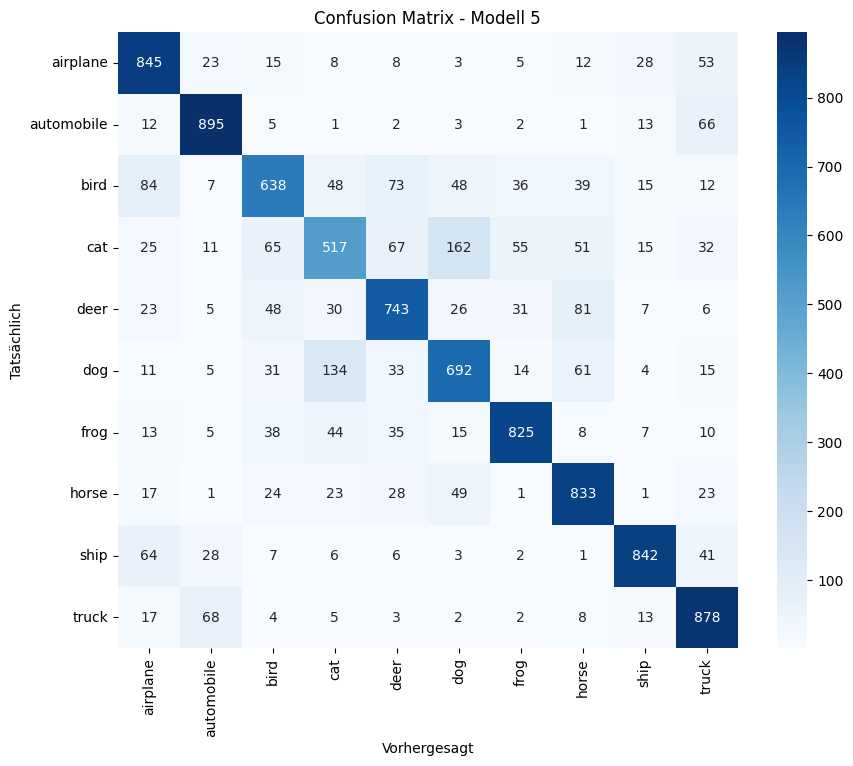

In [10]:
#Confusion Matrix + Metriken für Modell 5

from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

y_pred_5 = model_5.predict(X_test_norm)
y_pred_5_classes = y_pred_5.argmax(axis=1)

print(classification_report(y_test, y_pred_5_classes, target_names=class_names))

cm = confusion_matrix(y_test, y_pred_5_classes)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel('Vorhergesagt')
plt.ylabel('Tatsächlich')
plt.title('Confusion Matrix - Modell 5')
plt.show()

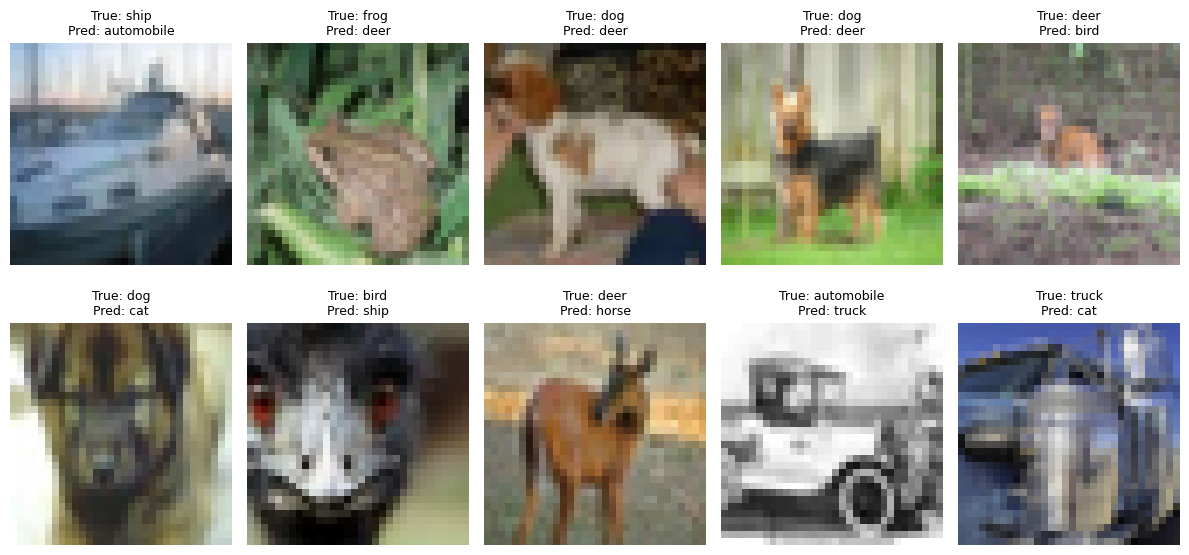

In [13]:
#Fehlerbeispiel-Bilder plotten
#confusion matrix + example errors

import numpy as np

wrong_indices = np.where(y_pred_5_classes != y_test.flatten())[0]

plt.figure(figsize=(12, 6))
for i, idx in enumerate(wrong_indices[:10]):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test_norm[idx])
    true_label = class_names[y_test[idx][0]]
    pred_label = class_names[y_pred_5_classes[idx]]
    plt.title(f"True: {true_label}\nPred: {pred_label}", fontsize=9)
    plt.axis('off')
plt.tight_layout()
plt.show()